In [1]:
# Import libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots in the notebook
%matplotlib inline

In [5]:
# Read the Excel file
df = pd.read_excel("06_Student Perfomance.xlsx")

In [6]:
df.head()

,gender,race_ethnicity,parental_level_of_education,math_score,reading_score,writing_score,total_score,average_score
0,0,group B,bachelor's degree,72,72,74,218,72.666667
1,0,group C,some college,69,90,88,247,82.333333
2,0,group B,master's degree,90,95,93,278,92.666667
3,1,group A,associate's degree,47,57,44,148,49.333333
4,1,group C,some college,76,78,75,229,76.333333


In [7]:
import os

os.listdir("/content")

['.config', '06_Student Perfomance.xlsx', 'sample_data']

In [8]:
# Number of rows and columns
df.shape

(202, 8)

In [9]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       202 non-null    int64  
 1   race_ethnicity               202 non-null    object 
 2   parental_level_of_education  199 non-null    object 
 3   math_score                   202 non-null    int64  
 4   reading_score                202 non-null    int64  
 5   writing_score                202 non-null    int64  
 6   total_score                  202 non-null    int64  
 7   average_score                198 non-null    float64
dtypes: float64(1), int64(5), object(2)
memory usage: 12.8+ KB


In [10]:
# Display column names
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'math_score',
       'reading_score', 'writing_score', 'total_score', 'average_score'],
      dtype='object')

In [11]:
# Display the first 5 rows
df.head()

,gender,race_ethnicity,parental_level_of_education,math_score,reading_score,writing_score,total_score,average_score
0,0,group B,bachelor's degree,72,72,74,218,72.666667
1,0,group C,some college,69,90,88,247,82.333333
2,0,group B,master's degree,90,95,93,278,92.666667
3,1,group A,associate's degree,47,57,44,148,49.333333
4,1,group C,some college,76,78,75,229,76.333333


In [12]:
# Check missing values
df.isnull().sum()

,0
gender,0
race_ethnicity,0
parental_level_of_education,3
math_score,0
reading_score,0
writing_score,0
total_score,0
average_score,4


In [13]:
# Check duplicate rows
df.duplicated().sum()

np.int64(3)

In [14]:
# Display rows with missing values
df[df.isnull().any(axis=1)]

,gender,race_ethnicity,parental_level_of_education,math_score,reading_score,writing_score,total_score,average_score
19,1,group C,master's degree,46,42,46,134,NaN
32,0,group B,some college,63,65,61,189,NaN
44,1,group B,some college,59,65,66,190,NaN
63,1,group A,NaN,39,39,34,112,37.333333
64,1,group A,NaN,39,39,34,112,37.333333
73,0,group D,NaN,58,63,73,194,64.666667
110,1,group E,associate's degree,66,63,64,193,NaN


In [15]:
# Remove duplicate rows
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
# Fill missing values in average_score
df["average_score"] = df["average_score"].fillna((df["math_score"] + df["reading_score"] + df["writing_score"]) / 3)

In [18]:
# Fill missing values in parental_level_of_education
df["parental_level_of_education"] = df["parental_level_of_education"].fillna(df["parental_level_of_education"].mode()[0])

In [19]:
# Check missing values again
df.isnull().sum()

,0
gender,0
race_ethnicity,0
parental_level_of_education,0
math_score,0
reading_score,0
writing_score,0
total_score,0
average_score,0


In [20]:
# Descriptive statistics for numerical variables
df.describe()

,gender,math_score,reading_score,writing_score,total_score,average_score
count,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,0.502513,64.216080,67.628141,66.366834,198.211055,66.070352
std,0.501255,15.903387,15.783971,16.259297,46.195081,15.398360
min,0.000000,0.000000,17.000000,10.000000,27.000000,9.000000
25%,0.000000,54.000000,55.500000,55.000000,165.000000,55.000000
50%,1.000000,65.000000,68.000000,68.000000,199.000000,66.333333
75%,1.000000,75.000000,79.000000,78.000000,233.000000,77.666667
max,1.000000,100.000000,100.000000,100.000000,299.000000,99.666667


In [21]:
# Descriptive statistics for score columns
score_columns = ["math_score", "reading_score", "writing_score", "total_score", "average_score"]

df[score_columns].describe()

,math_score,reading_score,writing_score,total_score,average_score
count,199.000000,199.000000,199.000000,199.000000,199.000000
mean,64.216080,67.628141,66.366834,198.211055,66.070352
std,15.903387,15.783971,16.259297,46.195081,15.398360
min,0.000000,17.000000,10.000000,27.000000,9.000000
25%,54.000000,55.500000,55.000000,165.000000,55.000000
50%,65.000000,68.000000,68.000000,199.000000,66.333333
75%,75.000000,79.000000,78.000000,233.000000,77.666667
max,100.000000,100.000000,100.000000,299.000000,99.666667


In [22]:
# Median of score columns
df[score_columns].median()

,0
math_score,65.000000
reading_score,68.000000
writing_score,68.000000
total_score,199.000000
average_score,66.333333


In [23]:
# Most common value of categorical variables
print(df["race_ethnicity"].mode())
print(df["parental_level_of_education"].mode())

0    group C
Name: race_ethnicity, dtype: object
0    associate's degree
Name: parental_level_of_education, dtype: object


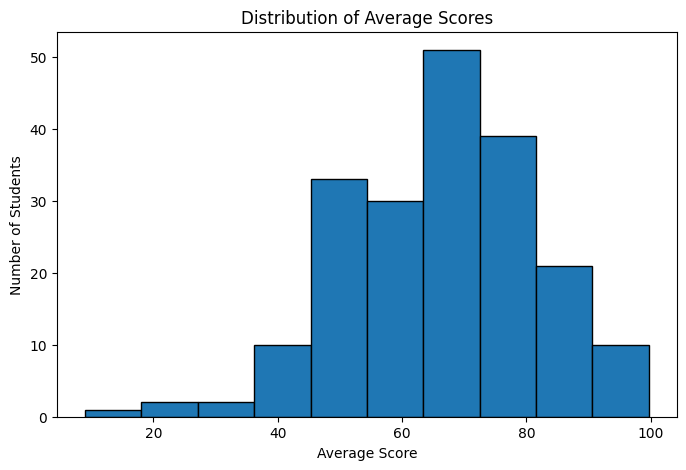

In [24]:
# Histogram of average scores

plt.figure(figsize=(8,5))

plt.hist(df["average_score"],
         bins=10,
         edgecolor="black")

plt.title("Distribution of Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")

plt.show()

/tmp/ipykernel_3017/4129309545.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


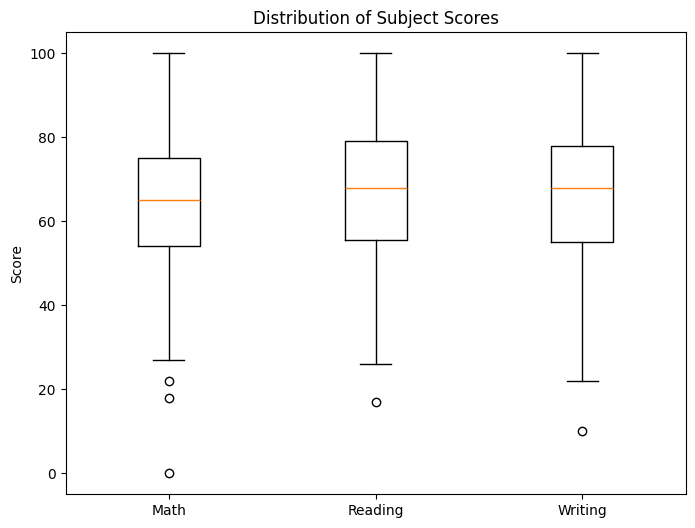

In [25]:
# Compare scores of three subjects

plt.figure(figsize=(8,6))

plt.boxplot([
    df["math_score"],
    df["reading_score"],
    df["writing_score"]
],
labels=["Math","Reading","Writing"])

plt.title("Distribution of Subject Scores")

plt.ylabel("Score")

plt.show()

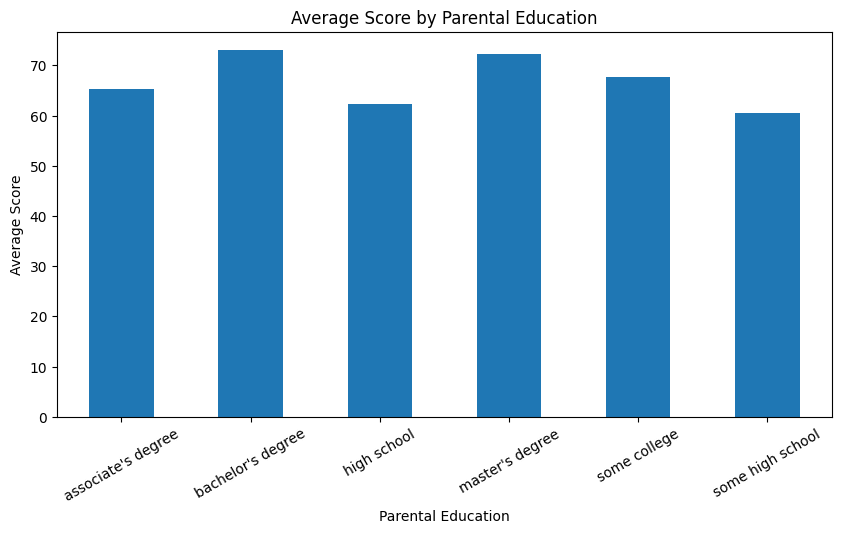

In [26]:
# Average score by parental education

avg = df.groupby("parental_level_of_education")["average_score"].mean()

plt.figure(figsize=(10,5))

avg.plot(kind="bar")

plt.title("Average Score by Parental Education")

plt.xlabel("Parental Education")

plt.ylabel("Average Score")

plt.xticks(rotation=30)

plt.show()